In [1]:
# Import pandas for DataFrame manipulation.
import pandas as pd

# Import numpy for numerical calculations.
import numpy as np

# Import matplotlib for visualization.
import matplotlib.pyplot as plt

# Import the column transformer for applying different preprocessing
# to numerical and categorical features.
from sklearn.compose import ColumnTransformer

# Import OneHotEncoder for converting categorical values into numerical vectors.
from sklearn.preprocessing import OneHotEncoder

# Import SimpleImputer for handling missing values.
from sklearn.impute import SimpleImputer

# Import Pipeline for chaining preprocessing steps together.
from sklearn.pipeline import Pipeline

# Import Linear Regression.
from sklearn.linear_model import LinearRegression

# Import Ridge Regression.
from sklearn.linear_model import Ridge

# Import Lasso Regression.
from sklearn.linear_model import Lasso

# Import Elastic Net Regression.
from sklearn.linear_model import ElasticNet

# Import Decision Tree Regression.
from sklearn.tree import DecisionTreeRegressor

# Import evaluation metrics.
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Import joblib for saving the trained model.
import joblib

In [2]:
# Load the cleaned dataset.
df = pd.read_csv(
    "../data/processed/flights_cleaned.csv"
)

# Print confirmation.
print("Dataset loaded successfully!")

# Display shape.
print("Shape:", df.shape)

# Display first five records.
df.head()

C:\Users\shini\AppData\Local\Temp\ipykernel_1748\302546408.py:2: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Dataset loaded successfully!
Shape: (5729194, 14)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_DELAY,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,DIVERTED
0,2015,1,1,4,AS,98,ANC,SEA,5,-11.0,205.0,1448,430,0
1,2015,1,1,4,AA,2336,LAX,PBI,10,-8.0,280.0,2330,750,0
2,2015,1,1,4,US,840,SFO,CLT,20,-2.0,286.0,2296,806,0
3,2015,1,1,4,AA,258,LAX,MIA,20,-5.0,285.0,2342,805,0
4,2015,1,1,4,AS,135,SEA,ANC,25,-1.0,235.0,1448,320,0


In [3]:
# List all categorical columns.
categorical_columns = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT"
]

# Loop through every categorical column.
for column in categorical_columns:

    # Convert the column to string.
    df[column] = df[column].astype(str)

# Print confirmation.
print("Categorical columns converted to string.")

Categorical columns converted to string.


In [5]:
# Extract scheduled departure hour.
# Example: 1830 becomes 18.
df["DEP_HOUR"] = (
    df["SCHEDULED_DEPARTURE"] // 100
)

# Extract scheduled departure minute.
# Example: 1830 becomes 30.
df["DEP_MINUTE"] = (
    df["SCHEDULED_DEPARTURE"] % 100
)

# Extract scheduled arrival hour.
df["ARR_HOUR"] = (
    df["SCHEDULED_ARRIVAL"] // 100
)

# Extract scheduled arrival minute.
df["ARR_MINUTE"] = (
    df["SCHEDULED_ARRIVAL"] % 100
)

# Convert 24 to 0 because 24:00 and 00:00 represent midnight.
df["ARR_HOUR"] = df["ARR_HOUR"].replace(
    24,
    0
)

In [6]:
# Convert departure hour into a circular sine representation.
df["DEP_HOUR_SIN"] = np.sin(
    2 * np.pi * df["DEP_HOUR"] / 24
)

# Convert departure hour into a circular cosine representation.
df["DEP_HOUR_COS"] = np.cos(
    2 * np.pi * df["DEP_HOUR"] / 24
)

# Convert arrival hour into a circular sine representation.
df["ARR_HOUR_SIN"] = np.sin(
    2 * np.pi * df["ARR_HOUR"] / 24
)

# Convert arrival hour into a circular cosine representation.
df["ARR_HOUR_COS"] = np.cos(
    2 * np.pi * df["ARR_HOUR"] / 24
)

In [7]:
# Combine origin and destination to create a route identifier.
df["ROUTE"] = (
    df["ORIGIN_AIRPORT"]
    + "_"
    + df["DESTINATION_AIRPORT"]
)

# Print a few routes.
print(df["ROUTE"].head())

0    ANC_SEA
1    LAX_PBI
2    SFO_CLT
3    LAX_MIA
4    SEA_ANC
Name: ROUTE, dtype: object


In [8]:
# Split the data according to time.
# Months 1-9 will be training data.
train_df = df[df["MONTH"] <= 9].copy()

# Months 10-12 will be test data.
test_df = df[df["MONTH"] >= 10].copy()

# Count how many times every route occurs in the training dataset.
route_counts = train_df["ROUTE"].value_counts()

# Map route frequencies to training records.
train_df["ROUTE_FREQUENCY"] = (
    train_df["ROUTE"]
    .map(route_counts)
    .fillna(0)
)

# Map the same training-derived frequencies to test records.
test_df["ROUTE_FREQUENCY"] = (
    test_df["ROUTE"]
    .map(route_counts)
    .fillna(0)
)

# Display train and test shapes.
print("Training shape:", train_df.shape)
print("Testing shape :", test_df.shape)

Training shape: (4310943, 24)
Testing shape : (1418251, 24)


In [9]:
# Our regression target is departure delay in minutes.
target = "DEPARTURE_DELAY"

# Print the target name.
print("Target:", target)

Target: DEPARTURE_DELAY


In [10]:
# Define the features that will be given to the model.
feature_columns = [

    # Month of the flight.
    "MONTH",

    # Day of the month.
    "DAY",

    # Day of the week.
    "DAY_OF_WEEK",

    # Airline code.
    "AIRLINE",

    # Origin airport.
    "ORIGIN_AIRPORT",

    # Destination airport.
    "DESTINATION_AIRPORT",

    # Scheduled flight duration.
    "SCHEDULED_TIME",

    # Flight distance.
    "DISTANCE",

    # Scheduled departure hour.
    "DEP_HOUR",

    # Scheduled departure minute.
    "DEP_MINUTE",

    # Scheduled arrival hour.
    "ARR_HOUR",

    # Scheduled arrival minute.
    "ARR_MINUTE",

    # Cyclical departure features.
    "DEP_HOUR_SIN",
    "DEP_HOUR_COS",

    # Cyclical arrival features.
    "ARR_HOUR_SIN",
    "ARR_HOUR_COS",

    # Route identifier.
    "ROUTE",

    # Number of training flights using this route.
    "ROUTE_FREQUENCY"
]

# Create training feature matrix.
X_train = train_df[feature_columns]

# Create training target.
y_train = train_df[target]

# Create test feature matrix.
X_test = test_df[feature_columns]

# Create test target.
y_test = test_df[target]

# Print shapes.
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (4310943, 18)
y_train: (4310943,)
X_test : (1418251, 18)
y_test : (1418251,)


In [11]:
# These features contain categories rather than continuous numerical values.
categorical_features = [

    # Airline is categorical.
    "AIRLINE",

    # Origin airport is categorical.
    "ORIGIN_AIRPORT",

    # Destination airport is categorical.
    "DESTINATION_AIRPORT",

    # Route is categorical.
    "ROUTE"
]

In [12]:
# These features are numerical values.
numeric_features = [

    # Calendar information.
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",

    # Scheduled flight information.
    "SCHEDULED_TIME",
    "DISTANCE",

    # Departure time.
    "DEP_HOUR",
    "DEP_MINUTE",

    # Arrival time.
    "ARR_HOUR",
    "ARR_MINUTE",

    # Cyclical time features.
    "DEP_HOUR_SIN",
    "DEP_HOUR_COS",
    "ARR_HOUR_SIN",
    "ARR_HOUR_COS",

    # Route frequency.
    "ROUTE_FREQUENCY"
]

In [13]:
# Create a pipeline for numerical features.
numeric_pipeline = Pipeline([

    # Replace missing numerical values with the median.
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

In [14]:
# Create a pipeline for categorical features.
categorical_pipeline = Pipeline([

    # Replace missing categories with the most frequent category.
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),

    # Convert categorical values into one-hot encoded vectors.
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

In [15]:
# Create a ColumnTransformer so different columns receive different preprocessing.
preprocessor = ColumnTransformer([

    # Apply numerical pipeline to numerical columns.
    (
        "num",
        numeric_pipeline,
        numeric_features
    ),

    # Apply categorical pipeline to categorical columns.
    (
        "cat",
        categorical_pipeline,
        categorical_features
    )
])

# Print confirmation.
print("Preprocessor created successfully.")

Preprocessor created successfully.


In [16]:
# Learn preprocessing rules from the training data
# and transform the training data.
X_train_processed = preprocessor.fit_transform(
    X_train
)

# Transform test data using ONLY the rules learned from training data.
X_test_processed = preprocessor.transform(
    X_test
)

# Display transformed shapes.
print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed testing shape:",
    X_test_processed.shape
)

Processed training shape: (4310943, 5284)
Processed testing shape: (1418251, 5284)


In [18]:
# Create a dictionary containing the regression algorithms.
models = {

    # Basic linear regression model.
    "Linear Regression":
        LinearRegression(),

    # Ridge adds L2 regularization.
    "Ridge Regression":
        Ridge(
            alpha=1.0,
            solver="lsqr"
        ),

    # Lasso adds L1 regularization.
    "Lasso Regression":
        Lasso(
            alpha=0.01,
            max_iter=5000,
            tol=0.001
        ),

    # Elastic Net combines L1 and L2 regularization.
    "Elastic Net":
        ElasticNet(
            alpha=0.01,
            l1_ratio=0.5,
            max_iter=5000,
            tol=0.001
        ),

    # Decision Tree learns non-linear relationships.
    "Decision Tree Regressor":
        DecisionTreeRegressor(
            max_depth=20,
            random_state=42
        )
}

In [19]:
# Create an empty list to store evaluation results.
results = []

# Loop through every model.
for model_name, model in models.items():

    # Print the current model.
    print(f"Training: {model_name}")

    # Train the model using the training data.
    model.fit(
        X_train_processed,
        y_train
    )

    # Generate predictions for the test dataset.
    predictions = model.predict(
        X_test_processed
    )

    # Calculate Mean Absolute Error.
    mae = mean_absolute_error(
        y_test,
        predictions
    )

    # Calculate Root Mean Squared Error.
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    # Calculate R-squared.
    r2 = r2_score(
        y_test,
        predictions
    )

    # Store the model results.
    results.append({

        # Store model name.
        "Model": model_name,

        # Store MAE.
        "MAE": mae,

        # Store RMSE.
        "RMSE": rmse,

        # Store R².
        "R2": r2
    })

    # Display metrics.
    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2  : {r2:.4f}")

    # Separator for readability.
    print("-" * 50)

Training: Linear Regression
MAE : 16.9073
RMSE: 36.0362
R2  : 0.0072
--------------------------------------------------
Training: Ridge Regression
MAE : 17.7366
RMSE: 36.1856
R2  : -0.0011
--------------------------------------------------
Training: Lasso Regression
MAE : 16.8776
RMSE: 36.0382
R2  : 0.0071
--------------------------------------------------
Training: Elastic Net
MAE : 16.9067
RMSE: 36.0360
R2  : 0.0072
--------------------------------------------------
Training: Decision Tree Regressor
MAE : 15.7727
RMSE: 40.2732
R2  : -0.2400
--------------------------------------------------


In [20]:
# Convert the results list into a DataFrame.
results_df = pd.DataFrame(results)

# Sort models by RMSE.
results_df = results_df.sort_values(
    by="RMSE",
    ascending=True
)

# Display the comparison.
results_df

,Model,MAE,RMSE,R2
3,Elastic Net,16.906655,36.036018,0.007204
0,Linear Regression,16.907309,36.036181,0.007195
2,Lasso Regression,16.877552,36.038203,0.007084
1,Ridge Regression,17.736613,36.185562,-0.001053
4,Decision Tree Regressor,15.772687,40.273181,-0.239990


In [21]:
# Select the first model after sorting by RMSE.
best_model_name = results_df.iloc[0]["Model"]

# Print the selected model name.
print(
    "Best model based on RMSE:",
    best_model_name
)

Best model based on RMSE: Elastic Net


In [22]:
# Retrieve the actual trained model object from the dictionary.
best_model = models[best_model_name]

# Print the model.
print(best_model)

ElasticNet(alpha=0.01, max_iter=5000, tol=0.001)


In [23]:
# Create the complete production package.
model_package = {

    # Store preprocessing logic.
    "preprocessor": preprocessor,

    # Store trained model.
    "model": best_model,

    # Store feature names.
    "features": feature_columns,

    # Store model name.
    "model_name": best_model_name,

    # Store the route-frequency mapping learned from training data.
    "route_frequency": route_counts.to_dict()
}

# Save everything into one file.
joblib.dump(
    model_package,
    "../models/regression_model.joblib"
)

# Confirm successful saving.
print("Complete production model package saved!")

Complete production model package saved!


In [25]:
# Load the saved model package from disk.
loaded_package = joblib.load(
    "../models/regression_model.joblib"
)

# Extract the preprocessing object.
loaded_preprocessor = (
    loaded_package["preprocessor"]
)

# Extract the trained model.
loaded_model = (
    loaded_package["model"]
)

# Transform the test data using the saved preprocessing object.
X_test_loaded = loaded_preprocessor.transform(
    X_test
)

# Generate predictions using the saved model.
loaded_predictions = loaded_model.predict(
    X_test_loaded
)

# Display a few predictions.
print(
    loaded_predictions[:10]
)

[ 2.43402482e-01 -3.20523199e-01  6.69765081e+00 -1.81848668e+00
 -1.84298029e+00  5.91522978e+00  6.08905037e+00 -4.87609289e-01
 -4.44041677e-03  7.43248329e-02]


In [26]:
# Calculate MAE using the saved model.
saved_mae = mean_absolute_error(
    y_test,
    loaded_predictions
)

# Calculate RMSE using the saved model.
saved_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        loaded_predictions
    )
)

# Calculate R² using the saved model.
saved_r2 = r2_score(
    y_test,
    loaded_predictions
)

# Display final metrics.
print("Saved Model Evaluation")
print("----------------------")
print("MAE :", saved_mae)
print("RMSE:", saved_rmse)
print("R2  :", saved_r2)

Saved Model Evaluation
----------------------
MAE : 16.90665514793162
RMSE: 36.036018202299594
R2  : 0.0072041626214922605


In [27]:
# Create a DataFrame containing actual and predicted delays.
comparison = pd.DataFrame({

    # Store actual delay values.
    "Actual": y_test.values,

    # Store predicted delay values.
    "Predicted": loaded_predictions
})

# Display the first 20 predictions.
comparison.head(20)

,Actual,Predicted
0,10.0,0.243402
1,11.0,-0.320523
2,-5.0,6.697651
3,-3.0,-1.818487
4,-2.0,-1.842980
5,-1.0,5.915230
6,-3.0,6.089050
7,0.0,-0.487609
8,2.0,-0.004440
9,-1.0,0.074325


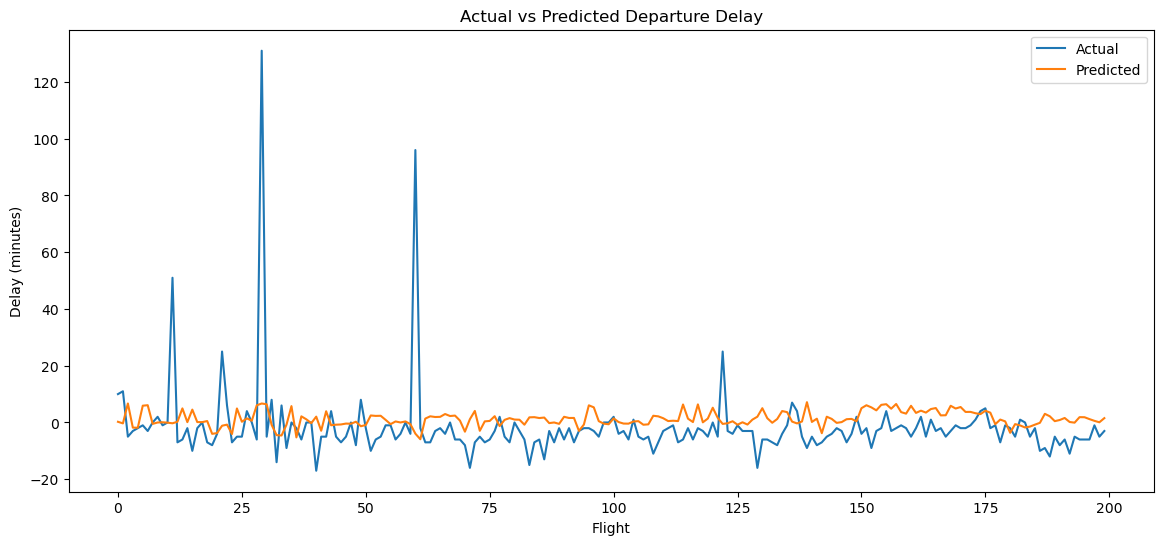

In [28]:
# Select a small sample so the graph remains readable.
plot_data = comparison.head(200)

# Create the figure.
plt.figure(figsize=(14, 6))

# Plot actual delay values.
plt.plot(
    plot_data["Actual"].values,
    label="Actual"
)

# Plot predicted delay values.
plt.plot(
    plot_data["Predicted"].values,
    label="Predicted"
)

# Add title.
plt.title(
    "Actual vs Predicted Departure Delay"
)

# Add axis labels.
plt.xlabel("Flight")

plt.ylabel("Delay (minutes)")

# Display legend.
plt.legend()

# Display graph.
plt.show()